# ECON4002 — Week 1: R Foundations for Economics

**University of Western Australia**  
*Essential R code snippets for basic operations, vectors, functions, and simple economic models*

---

## Key Formulae

Market equilibrium: $Q_d(P^*) = Q_s(P^*)$. Price elasticity: $\varepsilon = \frac{dQ}{dP} \cdot \frac{P}{Q}$

---

> **How to use:** Run each cell in order. Modify the parameters and re-run to explore the economics.

In [ ]:
# ECON4002 Week 1 — R Setup
# Run this cell first to configure options
options(scipen = 6, digits = 4)
cat('Week 1: R Foundations for Economics — ready!\n')

Week 1: R Foundations for Economics — ready!


## Basics

### W1-CS01 — Arithmetic Operations

Basic mathematical operations in R

> **Note:** R follows standard order of operations (PEMDAS). Use parentheses to override.

**Common errors:**
- Confusing %% (modulo) with % (not valid)
- Forgetting ^ for exponentiation

In [ ]:
# Basic arithmetic
2 + 3          # Addition: 5
10 - 4         # Subtraction: 6
5 * 6          # Multiplication: 30
20 / 4         # Division: 5
2^5            # Exponentiation: 32
17 %% 5        # Modulo (remainder): 2
17 %/% 5       # Integer division: 3

### W1-CS02 — Mathematical Functions

Common mathematical functions

> **Note:** log() is natural logarithm by default. Use log10() for base-10 or specify base=

**Common errors:**
- Assuming log() is base-10 (it's natural log)
- Forgetting exp() returns e^x

In [ ]:
# Square root and absolute value
sqrt(16)       # 4
abs(-5)        # 5

# Exponential and logarithms
exp(1)         # e = 2.718282
log(10)        # Natural log: 2.302585
log10(100)     # Log base 10: 2
log(8, base=2) # Log base 2: 3

# Constants
pi             # 3.141593

## Variables

### W1-CS03 — Variable Assignment

Creating and naming variables

> **Note:** Convention: use <- for assignment. Variable names are case-sensitive.

**Common errors:**
- Starting name with number (invalid)
- Using hyphens in names (use underscores)

In [ ]:
# Assignment (use <- or =)
price <- 25
quantity <- 100
revenue <- price * quantity
revenue        # 2500

# View all variables
ls()

# Remove variables
rm(price)              # Remove one
rm(list = ls())        # Remove ALL (careful!)

## Vectors

### W1-CS04 — Creating Vectors

Different ways to create vectors

> **Note:** c() combines elements. seq() creates sequences. rep() creates repetitions.

**Common errors:**
- Forgetting c() when creating vectors
- Confusing times= and each= in rep()

In [ ]:
# Combine elements with c()
prices <- c(250, 275, 300, 280, 290)
crops <- c("wheat", "corn", "soybean")

# Sequences
years <- 2020:2025                      # Integer sequence
by_two <- seq(0, 10, by = 2)            # 0, 2, 4, 6, 8, 10
five_points <- seq(0, 100, length.out = 5)  # 0, 25, 50, 75, 100

# Repetition
zeros <- rep(0, 5)                      # 0, 0, 0, 0, 0
pattern <- rep(c(1, 2), times = 3)      # 1, 2, 1, 2, 1, 2

### W1-CS05 — Vector Operations

Element-wise operations and summary functions

> **Note:** Operations are element-wise. Scalars are recycled to match vector length.

**Common errors:**
- Expecting matrix multiplication with * (use %*% for that)

In [ ]:
x <- c(1, 2, 3, 4, 5)
y <- c(10, 20, 30, 40, 50)

# Element-wise operations
x + y          # 11, 22, 33, 44, 55
x * y          # 10, 40, 90, 160, 250
x * 2          # 2, 4, 6, 8, 10 (scalar recycling)

# Summary functions
length(x)      # 5
sum(x)         # 15
mean(x)        # 3
sd(x)          # 1.581
min(x)         # 1
max(x)         # 5

### W1-CS06 — Indexing and Subsetting

Selecting elements from vectors

> **Note:** R uses 1-based indexing (first element is [1], not [0]). Negative indices exclude.

**Common errors:**
- Using [0] (returns empty vector)
- Forgetting R is 1-indexed

In [ ]:
prices <- c(250, 275, 300, 280, 290)

# Positive indexing (select)
prices[1]           # First element: 250 (R is 1-indexed!)
prices[c(1, 3, 5)]  # Elements 1, 3, 5
prices[2:4]         # Elements 2 through 4

# Negative indexing (exclude)
prices[-1]          # All except first

# Logical indexing
prices[prices > 280]  # Elements > 280: 300, 290

# Which indices?
which(prices > 280)   # Returns: 3, 5
which.max(prices)     # Index of max: 3

## Functions

### W1-CS07 — Creating Functions

Define custom functions with arguments

> **Note:** Functions use function() keyword. Default arguments go after required ones.

**Common errors:**
- Forgetting return() (last expression returned by default)
- Missing closing brace }

In [ ]:
# Basic function
calculate_revenue <- function(price, quantity) {
  revenue <- price * quantity
  return(revenue)
}

calculate_revenue(25, 100)  # 2500

# Function with default argument
profit <- function(revenue, cost, tax_rate = 0.20) {
  gross <- revenue - cost
  net <- gross * (1 - tax_rate)
  return(net)
}

profit(1000, 600)              # Uses default: 320
profit(1000, 600, tax_rate = 0.15)  # Override: 340

## Economics

### W1-CS08 — Demand and Supply Functions

Define linear demand and supply curves

> **Note:** pmax() ensures non-negative quantities (parallel maximum with 0).

> **Interpretation:** Demand slopes down (b > 0 gives negative slope). Supply slopes up (d > 0).

In [ ]:
# Demand: Qd = a - bP
demand <- function(P, a = 200, b = 4) {
  Qd <- a - b * P
  return(pmax(Qd, 0))  # Ensure non-negative
}

# Supply: Qs = c + dP
supply <- function(P, c = -20, d = 6) {
  Qs <- c + d * P
  return(pmax(Qs, 0))
}

# Test
demand(30)  # 200 - 4*30 = 80
supply(30)  # -20 + 6*30 = 160

### W1-CS09 — Finding Equilibrium

Solve for market equilibrium numerically

> **Note:** uniroot() finds where function equals zero. interval= specifies search range.

> **Interpretation:** Equilibrium where Qd = Qs. Excess demand = 0 means market clears.

In [ ]:
# Excess demand function
excess_demand <- function(P) {
  demand(P) - supply(P)
}

# Find P where excess demand = 0
equilibrium <- uniroot(excess_demand, interval = c(0, 100))
P_star <- equilibrium$root
Q_star <- demand(P_star)

cat("Equilibrium: P* =", round(P_star, 2), 
    ", Q* =", round(Q_star, 2))

### W1-CS10 — Market Visualization

Plot supply and demand curves

> **Note:** type='l' for line. lwd controls line width. pch controls point shape.

In [ ]:
# Generate data
P_range <- seq(0, 50, by = 0.5)
Qd <- demand(P_range)
Qs <- supply(P_range)

# Plot
plot(Qd, P_range, type = "l", col = "blue", lwd = 2,
     xlim = c(0, 250), ylim = c(0, 60),
     xlab = "Quantity", ylab = "Price",
     main = "Supply and Demand")
lines(Qs, P_range, col = "red", lwd = 2)

# Mark equilibrium
points(Q_star, P_star, pch = 19, cex = 1.5)

# Add reference lines
abline(h = P_star, lty = 2, col = "gray")
abline(v = Q_star, lty = 2, col = "gray")

# Legend and grid
legend("topright", c("Demand", "Supply"), 
       col = c("blue", "red"), lwd = 2)
grid()

### W1-CS11 — Elasticity Calculation

Calculate price elasticity of demand

> **Note:** Elasticity is negative for demand. |ε| > 1 is elastic, |ε| < 1 is inelastic.

> **Interpretation:** Inelastic demand: price increases raise total revenue. Elastic demand: price increases reduce revenue.

In [ ]:
# Point elasticity: ε = (dQ/dP) × (P/Q)
# For linear Qd = a - bP, dQ/dP = -b

elasticity_demand <- function(P, a = 200, b = 4) {
  Qd <- a - b * P
  dQ_dP <- -b
  epsilon <- dQ_dP * (P / Qd)
  return(epsilon)
}

# At equilibrium
epsilon_star <- elasticity_demand(P_star)
cat("Elasticity:", round(epsilon_star, 3))

# Interpretation
if (abs(epsilon_star) > 1) {
  cat("\nElastic: %ΔQ > %ΔP")
} else {
  cat("\nInelastic: %ΔQ < %ΔP")
}

### W1-CS12 — Tax Analysis

Analyze effect of per-unit tax on suppliers

> **Note:** Tax creates wedge between consumer price and producer price.

> **Interpretation:** Tax burden depends on relative elasticities. More inelastic side bears more burden.

In [ ]:
tax <- 5

# Supply with tax: suppliers receive (P - tax)
supply_tax <- function(P, c = -20, d = 6, t = tax) {
  Qs <- c + d * (P - t)
  return(pmax(Qs, 0))
}

# New equilibrium
excess_tax <- function(P) demand(P) - supply_tax(P)
eq_tax <- uniroot(excess_tax, c(0, 100))
P_consumer <- eq_tax$root
Q_new <- demand(P_consumer)
P_producer <- P_consumer - tax

# Tax burden
consumer_burden <- P_consumer - P_star
producer_burden <- P_star - P_producer

cat("Consumer pays: $", round(consumer_burden, 2), 
    " (", round(100*consumer_burden/tax), "%)\n")
cat("Producer pays: $", round(producer_burden, 2),
    " (", round(100*producer_burden/tax), "%)\n")

# Deadweight loss
DWL <- 0.5 * tax * (Q_star - Q_new)
cat("DWL: $", round(DWL, 2))

## Data

### W1-CS13 — Data Frames Preview

Create and manipulate basic data frames

> **Note:** Data frames are tables. Access columns with $ or [,]. Filter rows with logical conditions.

In [ ]:
# Create data frame
farm_data <- data.frame(
  crop = c("wheat", "corn", "soybean"),
  yield = c(45, 180, 50),
  price = c(7.50, 4.50, 13.00)
)

# Access columns
farm_data$yield        # By name
farm_data[, "yield"]   # Same
farm_data[, 2]         # By position

# Add column
farm_data$revenue <- farm_data$yield * farm_data$price

# Filter rows
farm_data[farm_data$yield > 50, ]

## Viewer Test: HTML Table Output

The cell below has a pre-rendered HTML table (simulating a data frame `print()`). This tests the notebook viewer's HTML output rendering.

In [ ]:
# Data frame display — output pre-rendered for viewer testing
farm_data <- data.frame(
  crop    = c('wheat', 'corn', 'soybean'),
  yield   = c(45, 180, 50),
  price   = c(7.50, 4.50, 13.00),
  revenue = c(337.50, 810.00, 650.00)
)
farm_data

,crop,yield,price,revenue
0,wheat,45,7.50,337.50
1,corn,180,4.50,810.00
2,soybean,50,13.00,650.00


## Viewer Test: Image Output

The cell below has a pre-rendered supply & demand plot. This tests the notebook viewer's image rendering.

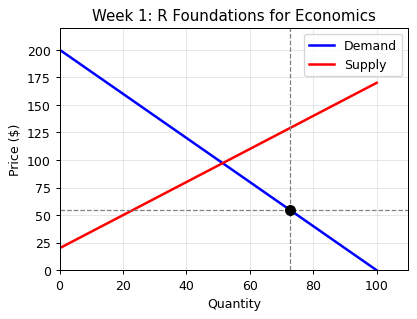

In [ ]:
# Supply & demand plot — output pre-rendered for viewer testing
P_range <- seq(0, 100, by = 0.5)
Qd <- 200 - 2 * P_range
Qs <- 20 + 1.5 * P_range
plot(Qd, P_range, type='l', col='blue', lwd=2,
     xlab='Quantity', ylab='Price', main='Supply & Demand')
lines(Qs, P_range, col='red', lwd=2)
legend('topright', c('Demand','Supply'), col=c('blue','red'), lty=1)

## Viewer Test: Empty Cell

The cell below is intentionally empty — the viewer should skip it gracefully.

## Common Patterns

**Economic Function**

```r
function_name <- function(args) {
  result <- calculation
  return(pmax(result, 0))  # Non-negative
}
```

**Find Equilibrium**

```r
excess <- function(P) demand(P) - supply(P)
eq <- uniroot(excess, c(lower, upper))
P_star <- eq$root
```

**Plot Two Curves**

```r
plot(x1, y1, type='l', col='blue')
lines(x2, y2, col='red')
legend('topright', c('Curve1', 'Curve2'), col=c('blue','red'), lty=1)
```

## Debugging Tips

| Error | Cause | Fix |
|-------|-------|-----|
| `object 'x' not found` | Variable not defined or typo in name | Check spelling and that variable was created |
| `could not find function` | Function name misspelled or package not loaded | Check spelling; load package with library() |
| `non-numeric argument to binary operator` | Trying to do math on non-numeric data | Check data types with class(); convert if needed |
| `replacement has length zero` | Assigning empty result to variable | Check that your calculation produces output |